In [1]:
"""Anhang-Chart A1: HG-6-Drilldown.

Zentrale Aussage: Der vermeintliche Peak 2023 in den laufenden Zuweisungen
ist ein Einmaleffekt der Mikroelektronik-Foerderung. Der stabile Kern
waechst stetig - kein Sprung, kein Crash.

Output: figures/anhang_a1_hg6_drilldown.png + .pdf
"""
import sys
from pathlib import Path
sys.path.insert(0, '..')  # repo root, relativ zum notebooks/-Verzeichnis

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from src import FIGURES_DIR
from src.load import load
from src.style import apply_style, COLORS, add_quelle

In [3]:
apply_style()
df = load()  # nutzt Repo-Root-Default aus src.load

In [4]:
# Daten
d = df[(df['any_tag']==1) & (df['digi_soll_eng']>0)].copy()
hg6 = d[d['hg']=='6'].copy()

In [5]:
is_mikro = (
    (hg6['einzelplan'] == 60)
    & (hg6['gruppe'] == 686)
    & (hg6['titel_text'].fillna('').str.contains('Mikroelektronik', case=False))
)
hg6_panel = hg6.groupby('id')['jahr'].nunique()
stable_ids = hg6_panel[hg6_panel==4].index

In [6]:
def kat(row):
    if (row['einzelplan']==60) and (row['gruppe']==686) and isinstance(row['titel_text'],str) and 'mikroelektronik' in row['titel_text'].lower():
        return 'Mikroelektronik (EP 60, Einmaleffekt)'
    if row['id'] in stable_ids:
        return 'Stabiler Kern (Panel-Titel in allen Jahren)'
    return 'Sonstige laufende Zuweisungen'

In [7]:
hg6['kat'] = hg6.apply(kat, axis=1)
agg = hg6.groupby(['jahr','kat'])['digi_soll_eng'].sum().div(1e6).unstack().fillna(0)

In [8]:
# Reihenfolge fuer Stack: stabiler Kern unten, dann sonstige, dann Mikro
kat_order = ['Stabiler Kern (Panel-Titel in allen Jahren)',
             'Sonstige laufende Zuweisungen',
             'Mikroelektronik (EP 60, Einmaleffekt)']
farben = {
    'Stabiler Kern (Panel-Titel in allen Jahren)': COLORS['akzent_2'],
    'Sonstige laufende Zuweisungen': COLORS['neutral'],
    'Mikroelektronik (EP 60, Einmaleffekt)': COLORS['highlight'],
}

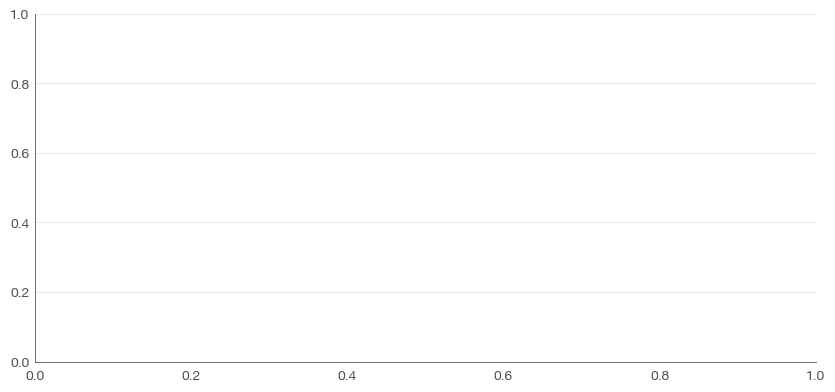

In [9]:
# Plot
fig, ax = plt.subplots(figsize=(11, 5.8))
fig.subplots_adjust(left=0.07, right=0.78, top=0.78, bottom=0.18)

In [10]:
jahre = sorted(agg.index)
x = np.arange(len(jahre))
bottom = np.zeros(len(jahre))

In [11]:
for k in kat_order:
    werte = agg.loc[jahre, k].values
    ax.bar(x, werte, bottom=bottom, color=farben[k], label=k,
           edgecolor='white', linewidth=1.5, width=0.62)
    # Beschriftung Mikroelektronik direkt im Balken
    if k == 'Mikroelektronik (EP 60, Einmaleffekt)':
        for i, v in enumerate(werte):
            if v > 0.1:
                ax.text(x[i], bottom[i] + v/2, f'{v:.2f} Mrd',
                        ha='center', va='center', fontsize=10,
                        color='white', weight='bold')
    bottom += werte

In [12]:
# Gesamt-Beschriftung ueber dem Stack
for i, j in enumerate(jahre):
    ax.text(x[i], bottom[i] + 0.15, f'{bottom[i]:.2f}',
            ha='center', fontsize=10, color=COLORS['text_secondary'])

In [13]:
ax.set_xticks(x)
ax.set_xticklabels([str(j) for j in jahre])
ax.set_ylim(0, 9.2)
ax.set_ylabel('Mrd € (digi_soll_eng)')

Text(4.444444444444445, 0.5, 'Mrd € (digi_soll_eng)')

In [14]:
# Titel
fig.text(0.04, 0.93,
         'Anhang A1: Der HG-6-Peak 2023 ist ein Einmaleffekt',
         fontsize=14, weight='medium', color=COLORS['text'])
fig.text(0.04, 0.89,
         'Laufende Zuweisungen (Hauptgruppe 6) im Digitalhaushalt, aufgeteilt nach Komponenten',
         fontsize=10, color=COLORS['text_secondary'])

Text(0.04, 0.89, 'Laufende Zuweisungen (Hauptgruppe 6) im Digitalhaushalt, aufgeteilt nach Komponenten')

In [15]:
# Rechte Spalte: Kontext-Erlaeuterung
y0 = 0.78
fig.text(0.80, y0, 'Was der Peak verrät',
         fontsize=11, color=COLORS['text'], weight='medium')
fig.text(0.80, y0-0.06,
         'Die 2,74 Mrd. €\nMikroelektronik-Förderung\n2023 sind eine einmalige\nVerpflichtungs-\nermächtigung',
         fontsize=9, color=COLORS['text_secondary'], linespacing=1.4)
fig.text(0.80, y0-0.30,
         '(Deutsche Beteiligung\nam EU-Chips-Act,\nIntel und ESMC).',
         fontsize=9, color=COLORS['text_tertiary'], linespacing=1.4)
fig.text(0.80, y0-0.46,
         'Ohne diesen Posten:',
         fontsize=9, color=COLORS['text_secondary'])
fig.text(0.80, y0-0.51,
         '+42 %',
         fontsize=18, color=COLORS['akzent_2'], weight='bold')
fig.text(0.80, y0-0.57,
         'stetiges Wachstum\ndes stabilen Kerns\n2019–2024 (2,22→3,16 Mrd).',
         fontsize=9, color=COLORS['text_tertiary'], linespacing=1.4)

Text(0.8, 0.21000000000000008, 'stetiges Wachstum\ndes stabilen Kerns\n2019–2024 (2,22→3,16 Mrd).')

In [16]:
# Legende unten links
from matplotlib.patches import Patch
handles = [Patch(facecolor=farben[k], label=k) for k in kat_order]
fig.legend(handles=handles, loc='lower center',
           bbox_to_anchor=(0.42, 0.005), ncol=1, frameon=False,
           fontsize=9, alignment='left')

In [17]:
fig.text(0.04, 0.02,
         'Quelle: Digitalhaushalt Open Data (ZEW/Agora), enge Abgrenzung. Stabiler Kern = HG-6-Titel mit Vorkommen in allen vier Jahren.',
         fontsize=8, color=COLORS['text_tertiary'], style='italic')

Text(0.04, 0.02, 'Quelle: Digitalhaushalt Open Data (ZEW/Agora), enge Abgrenzung. Stabiler Kern = HG-6-Titel mit Vorkommen in allen vier Jahren.')

In [18]:
out_dir = FIGURES_DIR
fig.savefig(out_dir / 'anhang_a1_hg6_drilldown.png', dpi=200)
fig.savefig(out_dir / 'anhang_a1_hg6_drilldown.pdf')
print(f"Gespeichert: {out_dir/'anhang_a1_hg6_drilldown.png'}")
print(f"Gespeichert: {out_dir/'anhang_a1_hg6_drilldown.pdf'}")

Gespeichert: /Users/moe/Documents/GitHub/agora_challenge/figures/anhang_a1_hg6_drilldown.png
Gespeichert: /Users/moe/Documents/GitHub/agora_challenge/figures/anhang_a1_hg6_drilldown.pdf


/var/folders/xm/gs28jq6d06v82tq2zhvmw96r0000gn/T/ipykernel_93639/2552863937.py:2: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.savefig(out_dir / 'anhang_a1_hg6_drilldown.png', dpi=200)
/var/folders/xm/gs28jq6d06v82tq2zhvmw96r0000gn/T/ipykernel_93639/2552863937.py:3: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.savefig(out_dir / 'anhang_a1_hg6_drilldown.pdf')
